# JBot Database Analytics Dashboard

This notebook provides comprehensive analytics for the `jbot.db` database, including:
- Database health and structure
- Player engagement and performance metrics
- Power-up usage and effectiveness
- Question usage patterns
- Streak and bonus analysis

## 1. Setup and Database Connection

This notebook assumes that `jbot.db` is in the same directory. Update the `db_file` variable below if needed.

In [1]:
import sqlite3
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime, timedelta

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

db_file = "jbot.db"

if not os.path.exists(db_file):
    print(
        f"Database file '{db_file}' not found. Please ensure it is in the same directory as this notebook."
    )
    conn = None
else:
    conn = sqlite3.connect(db_file)
    print("✓ Successfully connected to the database.")

✓ Successfully connected to the database.


## 2. Database Size and Record Counts

This section provides a high-level overview of the database's size on disk and the number of records in each table.


In [2]:
if "conn" in locals() and conn:
    # Get database file size
    db_size = os.path.getsize(db_file)
    print(
        f"Database file size: {db_size / 1024:.2f} KB ({db_size / (1024*1024):.2f} MB)"
    )

    # Get record counts for each table
    # Use an allowlist from sqlite_master to avoid SQL injection via table names
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = [row[0] for row in cursor.fetchall()]

    record_counts = []
    for table_name in tables:
        safe_name = table_name.replace('"', "")
        cursor.execute(f'SELECT COUNT(*) FROM "{safe_name}"')
        count = cursor.fetchone()[0]
        record_counts.append({"Table": table_name, "Record Count": count})

    df_counts = pd.DataFrame(record_counts)
    df_counts = df_counts.sort_values("Record Count", ascending=False)
    print("\n📊 Record counts per table:")
    print(df_counts.to_string(index=False))

Database file size: 1204.00 KB (1.18 MB)

📊 Record counts per table:
              Table  Record Count
            guesses          4383
           messages          1704
daily_player_states          1571
    daily_questions           220
          questions           202
      powerup_usage           135
  score_adjustments            71
            players            18
    sqlite_sequence             9
alternative_answers             9
              roles             2
        subscribers             1
       player_roles             1
            seasons             0
      season_scores             0
  season_challenges             0
season_daily_scores             0


## 3. Player Engagement & Performance Metrics

Comprehensive analysis of player activity, accuracy, and competitive performance.

🏆 Top Players Leaderboard
            name  score  current_streak  correct_answers  days_participated  accuracy_pct
           lanie  23502               8              157                164          48.5
           Blake  23019               4              167                183          32.3
           Kenny  19252               7              135                162          23.8
         TaoMike  19132               6              120                129          43.2
         Kristen  18441               3              132                152          32.9
        Kimberly  17202              15              114                126          30.0
       Juniornlx  15863               4              113                143          35.4
    bunnyfarts83  15841               4              103                124          27.2
      DrKnickers  13566               1               96                112          37.1
        Jonathan  11560               0               95                11

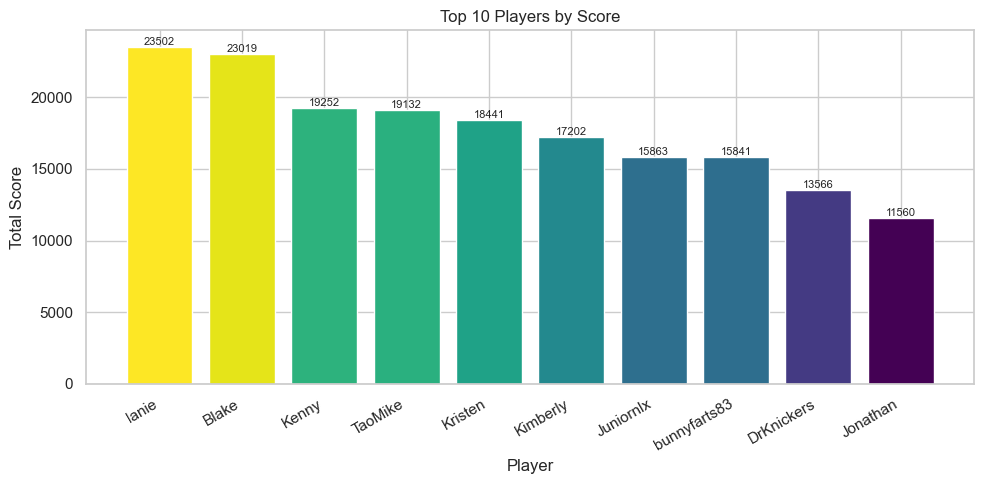

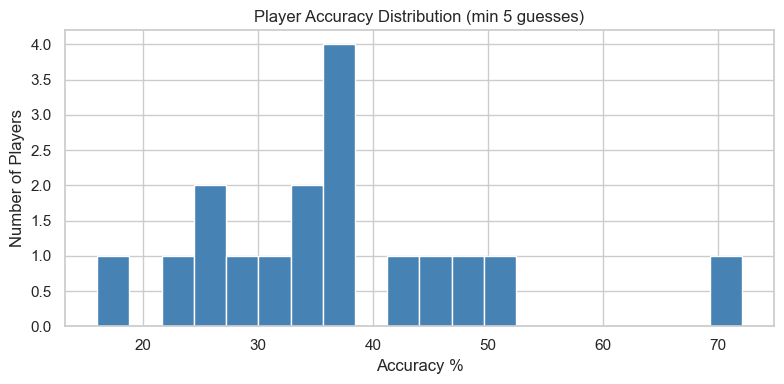

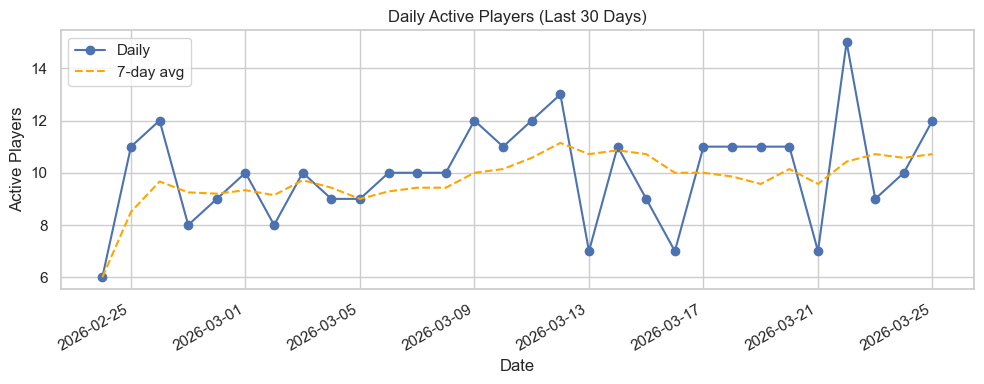


📈 Player Activity Summary:
Total players with guesses: 18
Active in last 7 days: 17
Active in last 30 days: 17


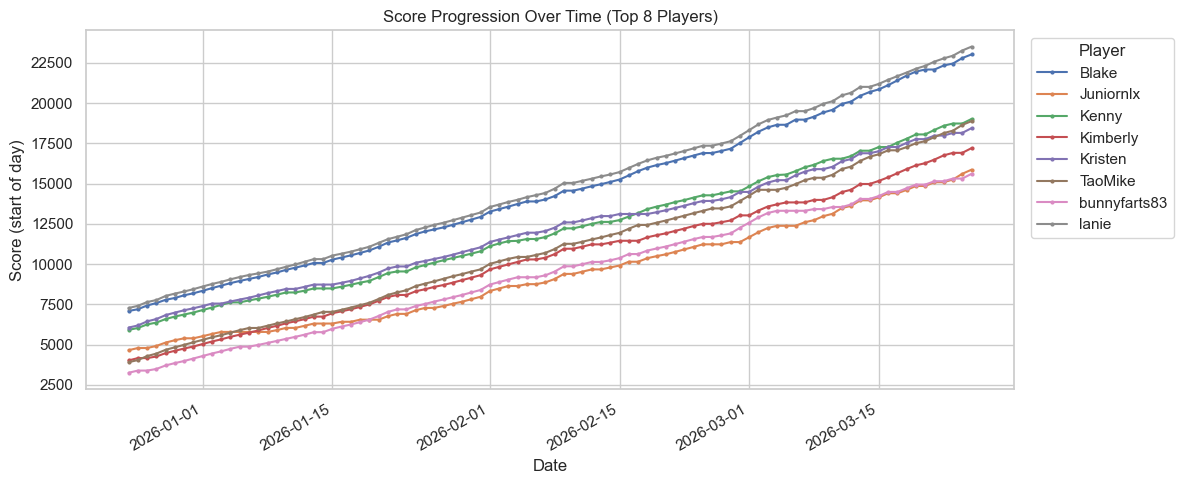


😴 Inactive Players (no activity in 14+ days):
  1 player(s) have gone quiet:
         name last_active  total_days_played
Presto_Manqué  2025-12-21                  8


In [3]:
if "conn" in locals() and conn:
    # Top Players by Score
    query = """
    SELECT
        p.name,
        p.score,
        p.answer_streak as current_streak,
        COUNT(DISTINCT CASE WHEN g.is_correct = 1 THEN g.daily_question_id END) as correct_answers,
        COUNT(DISTINCT g.daily_question_id) as days_participated,
        ROUND(100.0 * COUNT(CASE WHEN g.is_correct = 1 THEN 1 END) / COUNT(g.id), 1) as accuracy_pct
    FROM players p
    LEFT JOIN guesses g ON p.id = g.player_id
    GROUP BY p.id, p.name, p.score, p.answer_streak
    ORDER BY p.score DESC
    LIMIT 15;
    """
    df_leaderboard = pd.read_sql_query(query, conn)
    print("🏆 Top Players Leaderboard")
    print(df_leaderboard.to_string(index=False))

    # Top 10 by score — bars labelled with values
    top10 = df_leaderboard.head(10)
    norm = plt.Normalize(top10["score"].min(), top10["score"].max())
    colors = plt.cm.viridis(norm(top10["score"]))
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(top10["name"], top10["score"], color=colors)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height())}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
    ax.set_title("Top 10 Players by Score")
    ax.set_xlabel("Player")
    ax.set_ylabel("Total Score")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

    # Player Accuracy Distribution
    query = """
    SELECT
        p.name,
        ROUND(100.0 * COUNT(CASE WHEN g.is_correct = 1 THEN 1 END) / COUNT(g.id), 1) as accuracy
    FROM players p
    INNER JOIN guesses g ON p.id = g.player_id
    GROUP BY p.id, p.name
    HAVING COUNT(g.id) >= 5
    ORDER BY accuracy DESC;
    """
    df_accuracy = pd.read_sql_query(query, conn)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df_accuracy["accuracy"], bins=20, color="steelblue", edgecolor="white")
    ax.set_title("Player Accuracy Distribution (min 5 guesses)")
    ax.set_xlabel("Accuracy %")
    ax.set_ylabel("Number of Players")
    plt.tight_layout()
    plt.show()

    # Active Player Trends (last 30 days) with 7-day rolling average
    query = """
    SELECT
        DATE(g.guessed_at) as date,
        COUNT(DISTINCT g.player_id) as active_players
    FROM guesses g
    WHERE g.guessed_at >= DATE('now', '-30 days')
    GROUP BY DATE(g.guessed_at)
    ORDER BY date;
    """
    df_active = pd.read_sql_query(query, conn)
    if not df_active.empty:
        df_active["date"] = pd.to_datetime(df_active["date"])
        df_active["rolling_7d"] = (
            df_active["active_players"].rolling(7, min_periods=1).mean()
        )
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(
            df_active["date"], df_active["active_players"], marker="o", label="Daily"
        )
        ax.plot(
            df_active["date"],
            df_active["rolling_7d"],
            linestyle="--",
            color="orange",
            label="7-day avg",
        )
        ax.set_title("Daily Active Players (Last 30 Days)")
        ax.set_xlabel("Date")
        ax.set_ylabel("Active Players")
        ax.legend()
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    # Total Participation Summary
    query = """
    SELECT
        COUNT(DISTINCT player_id) as total_players,
        COUNT(DISTINCT CASE WHEN guessed_at >= DATE('now', '-7 days') THEN player_id END) as active_last_7d,
        COUNT(DISTINCT CASE WHEN guessed_at >= DATE('now', '-30 days') THEN player_id END) as active_last_30d
    FROM guesses;
    """
    df_summary = pd.read_sql_query(query, conn)
    print("\n📈 Player Activity Summary:")
    print(f"Total players with guesses: {df_summary.iloc[0]['total_players']}")
    print(f"Active in last 7 days: {df_summary.iloc[0]['active_last_7d']}")
    print(f"Active in last 30 days: {df_summary.iloc[0]['active_last_30d']}")

    # Score progression over time (start-of-day snapshots from daily_player_states)
    query = """
    SELECT
        p.name,
        dq.sent_at,
        dps.score
    FROM daily_player_states dps
    JOIN players p ON dps.player_id = p.id
    JOIN daily_questions dq ON dps.daily_question_id = dq.id
    ORDER BY dq.sent_at, p.name;
    """
    df_progression = pd.read_sql_query(query, conn)
    if not df_progression.empty:
        df_progression["sent_at"] = pd.to_datetime(df_progression["sent_at"])
        top_players = df_leaderboard["name"].head(8).tolist()
        df_top_prog = df_progression[df_progression["name"].isin(top_players)]
        if not df_top_prog.empty:
            fig, ax = plt.subplots(figsize=(12, 5))
            for player, grp in df_top_prog.groupby("name"):
                ax.plot(
                    grp["sent_at"],
                    grp["score"],
                    marker=".",
                    markersize=4,
                    label=player,
                )
            ax.set_title("Score Progression Over Time (Top 8 Players)")
            ax.set_xlabel("Date")
            ax.set_ylabel("Score (start of day)")
            ax.legend(title="Player", bbox_to_anchor=(1.01, 1), loc="upper left")
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plt.show()

    # Inactive player tracking (no activity in 14+ days)
    query = """
    SELECT
        p.name,
        MAX(DATE(g.guessed_at)) as last_active,
        COUNT(DISTINCT g.daily_question_id) as total_days_played
    FROM players p
    JOIN guesses g ON p.id = g.player_id
    GROUP BY p.id, p.name
    HAVING MAX(g.guessed_at) < DATE('now', '-14 days')
    ORDER BY last_active DESC;
    """
    df_inactive = pd.read_sql_query(query, conn)
    print("\n😴 Inactive Players (no activity in 14+ days):")
    if not df_inactive.empty:
        print(f"  {len(df_inactive)} player(s) have gone quiet:")
        print(df_inactive.to_string(index=False))
    else:
        print("  ✓ All players active within the last 14 days")

## 4. Power-Up Usage & Effectiveness

Analysis of power-up mechanics, including usage patterns and streak performance.

⚡ Power-Up Usage Statistics:
 powerup_type  usage_count  unique_users
        steal           43             8
         jinx           34             6
         rest           28             8
  rest_wakeup           15             6
       shield           11             2
 jinx_preload            2             2
steal_preload            1             1
    jinx_late            1             1


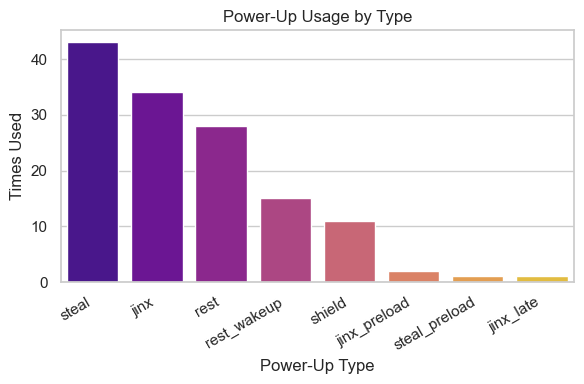

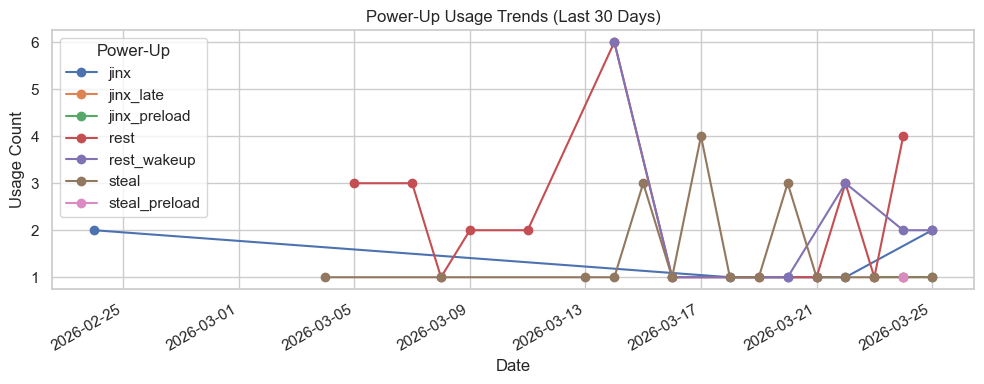


🎯 Power-Up Usage by Player:
        name  jinx  jinx_late  jinx_preload  rest  rest_wakeup  shield  steal  steal_preload
       lanie   7.0        0.0           1.0   2.0          1.0    10.0    9.0            1.0
       Kenny   5.0        0.0           0.0   6.0          4.0     0.0   13.0            0.0
       Blake  13.0        1.0           1.0   2.0          0.0     1.0    7.0            0.0
     Kristen   2.0        0.0           0.0   5.0          3.0     0.0    3.0            0.0
    Jonathan   6.0        0.0           0.0   0.0          0.0     0.0    5.0            0.0
bunnyfarts83   0.0        0.0           0.0   5.0          3.0     0.0    1.0            0.0
    Kimberly   1.0        0.0           0.0   5.0          2.0     0.0    0.0            0.0
   Juniornlx   0.0        0.0           0.0   2.0          2.0     0.0    0.0            0.0
     TaoMike   0.0        0.0           0.0   1.0          0.0     0.0    3.0            0.0
      Lariss   0.0        0.0           0

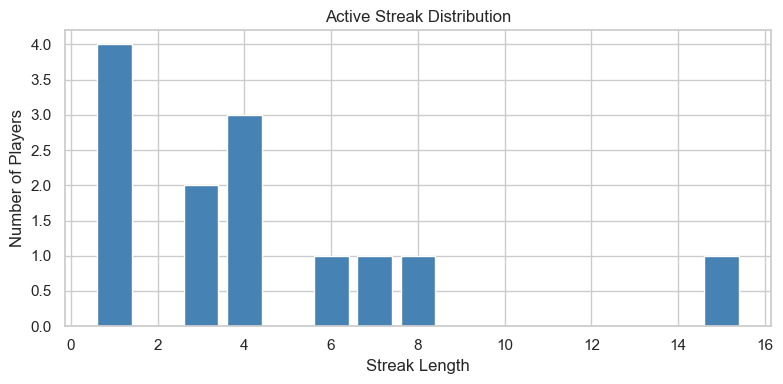

In [4]:
if "conn" in locals() and conn:
    # Power-up usage by type
    query = """
    SELECT
        powerup_type,
        COUNT(*) as usage_count,
        COUNT(DISTINCT user_id) as unique_users
    FROM powerup_usage
    GROUP BY powerup_type
    ORDER BY usage_count DESC;
    """
    df_powerups = pd.read_sql_query(query, conn)

    if not df_powerups.empty:
        print("⚡ Power-Up Usage Statistics:")
        print(df_powerups.to_string(index=False))

        fig, ax = plt.subplots(figsize=(6, 4))
        sns.barplot(
            data=df_powerups,
            x="powerup_type",
            y="usage_count",
            ax=ax,
            hue="powerup_type",
            palette="plasma",
            legend=False,
        )
        ax.set_title("Power-Up Usage by Type")
        ax.set_xlabel("Power-Up Type")
        ax.set_ylabel("Times Used")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

        # Power-up usage over time
        query = """
        SELECT
            DATE(used_at) as date,
            powerup_type,
            COUNT(*) as count
        FROM powerup_usage
        WHERE used_at >= DATE('now', '-30 days')
        GROUP BY DATE(used_at), powerup_type
        ORDER BY date;
        """
        df_powerup_trends = pd.read_sql_query(query, conn)
        if not df_powerup_trends.empty:
            df_powerup_trends["date"] = pd.to_datetime(df_powerup_trends["date"])
            fig, ax = plt.subplots(figsize=(10, 4))
            for ptype, grp in df_powerup_trends.groupby("powerup_type"):
                ax.plot(grp["date"], grp["count"], marker="o", label=ptype)
            ax.set_title("Power-Up Usage Trends (Last 30 Days)")
            ax.set_xlabel("Date")
            ax.set_ylabel("Usage Count")
            ax.legend(title="Power-Up")
            plt.xticks(rotation=30, ha="right")
            plt.tight_layout()
            plt.show()

        # Power-up users — pivoted: one row per player, one column per powerup type
        query = """
        SELECT
            p.name,
            pu.powerup_type,
            COUNT(*) as times_used
        FROM powerup_usage pu
        JOIN players p ON pu.user_id = p.id
        GROUP BY pu.user_id, p.name, pu.powerup_type;
        """
        df_top_users_raw = pd.read_sql_query(query, conn)
        df_pivot = df_top_users_raw.pivot_table(
            index="name", columns="powerup_type", values="times_used", fill_value=0
        ).reset_index()
        df_pivot.columns.name = None
        numeric_cols = [c for c in df_pivot.columns if c != "name"]
        df_pivot["total"] = df_pivot[numeric_cols].sum(axis=1)
        df_pivot = df_pivot.sort_values("total", ascending=False).drop(columns="total")
        print("\n🎯 Power-Up Usage by Player:")
        print(df_pivot.to_string(index=False))

        # Overnight pre-loads (queued before the question was posted)
        query = """
        SELECT
            powerup_type,
            COUNT(*) as preload_count,
            COUNT(DISTINCT user_id) as unique_users
        FROM powerup_usage
        WHERE question_id IS NULL
        GROUP BY powerup_type
        ORDER BY preload_count DESC;
        """
        df_preloads = pd.read_sql_query(query, conn)
        if not df_preloads.empty:
            print(
                "\n🌙 Overnight Pre-loaded Power-Ups (queued before question posted):"
            )
            print(df_preloads.to_string(index=False))
    else:
        print("No power-up usage data found.")

    # Streak Analysis
    print("\n\n🔥 Answer Streak Analysis:")
    query = """
    SELECT
        p.name,
        p.answer_streak as current_streak,
        p.score
    FROM players p
    WHERE p.answer_streak > 0
    ORDER BY p.answer_streak DESC
    LIMIT 10;
    """
    df_streaks = pd.read_sql_query(query, conn)
    if not df_streaks.empty:
        print("Top Current Streaks:")
        print(df_streaks.to_string(index=False))

        # Streak distribution
        query = """
        SELECT
            answer_streak,
            COUNT(*) as player_count
        FROM players
        WHERE answer_streak > 0
        GROUP BY answer_streak
        ORDER BY answer_streak;
        """
        df_streak_dist = pd.read_sql_query(query, conn)
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.bar(
            df_streak_dist["answer_streak"],
            df_streak_dist["player_count"],
            color="steelblue",
        )
        ax.set_title("Active Streak Distribution")
        ax.set_xlabel("Streak Length")
        ax.set_ylabel("Number of Players")
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        plt.tight_layout()
        plt.show()
    else:
        print("No active streaks found.")

## 5. Question Usage & Dataset Analysis

Analysis of trivia questions, including usage rates by source dataset and difficulty patterns.

📚 Question Pool Statistics:
Total questions available: 202
Unique questions used: 188
Usage percentage: 93.1%
Remaining unused: 14

📊 Question Usage by Source Dataset:
                                       source  total_questions  used_questions  avg_value  questions_with_hints  usage_pct  hint_pct
                           Riddles with Hints               62              35      100.0                    30       56.5      48.4
                                   5th Grader               62              60      100.0                    62       96.8     100.0
                                    Jeopardy!               29              29      186.2                    29      100.0     100.0
                                          NaN               23              18      100.0                    16       78.3      69.6
          Are You Smarter Than a Fifth Grader               22              22      100.0                    22      100.0     100.0
                                ge

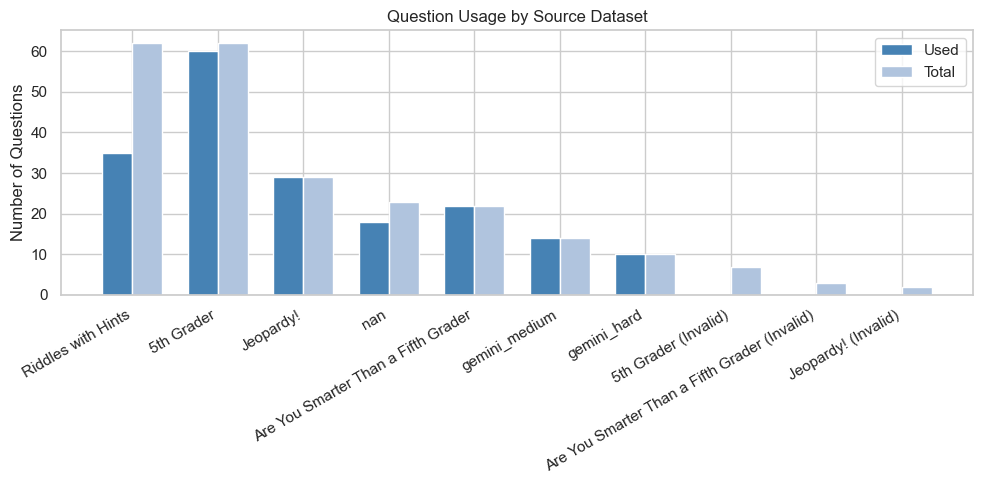

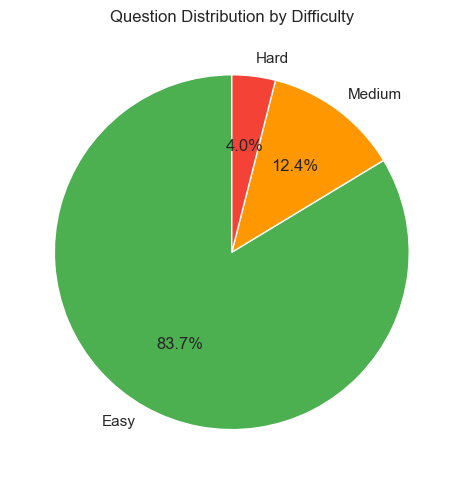


📅 Recently Used Questions:
                                               question_preview                              source  value    sent_at
Sailing on behalf of Spain in 1519, this Portuguese explorer...                           Jeopardy!    200 2026-03-25
Shaka instituted a type of close-combat fighting involving s...                           Jeopardy!    200 2026-03-24
           I am history's most famous paper cut for a crown....                         gemini_hard    300 2026-03-23
             Which famous American made the first telephone?... Are You Smarter Than a Fifth Grader    100 2026-03-22
Last line of "There was an old woman lived under the hill, &...                           Jeopardy!    200 2026-03-21
Tom yum goong from Thailand is made with prawns & this, Cymb...                           Jeopardy!    200 2026-03-20
             Ankara is the capital of what European country?... Are You Smarter Than a Fifth Grader    100 2026-03-19
When developed in 1927, this

In [5]:
if "conn" in locals() and conn:
    # Total questions vs. Used questions
    query_total = "SELECT COUNT(*) FROM questions;"
    total_questions = pd.read_sql_query(query_total, conn).iloc[0, 0]

    query_used = "SELECT COUNT(DISTINCT question_id) FROM daily_questions;"
    used_questions = pd.read_sql_query(query_used, conn).iloc[0, 0]

    print(f"📚 Question Pool Statistics:")
    print(f"Total questions available: {total_questions}")
    print(f"Unique questions used: {used_questions}")
    if total_questions > 0:
        print(f"Usage percentage: {used_questions / total_questions * 100:.1f}%")
        print(f"Remaining unused: {total_questions - used_questions}")

    # Question usage by source with enhanced metrics
    query = """
    SELECT
        q.source,
        COUNT(q.id) as total_questions,
        COUNT(DISTINCT dq.question_id) as used_questions,
        ROUND(AVG(q.value), 1) as avg_value,
        COUNT(DISTINCT CASE WHEN q.hint_text IS NOT NULL THEN q.id END) as questions_with_hints
    FROM questions q
    LEFT JOIN daily_questions dq ON q.id = dq.question_id
    GROUP BY q.source
    ORDER BY total_questions DESC;
    """
    df_source = pd.read_sql_query(query, conn)
    df_source["usage_pct"] = (
        df_source["used_questions"] / df_source["total_questions"] * 100
    ).round(1)
    df_source["hint_pct"] = (
        df_source["questions_with_hints"] / df_source["total_questions"] * 100
    ).round(1)

    print("\n📊 Question Usage by Source Dataset:")
    print(df_source.to_string(index=False))

    # Grouped bar: used vs. total by source
    x = range(len(df_source))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(
        [i - width / 2 for i in x],
        df_source["used_questions"],
        width,
        label="Used",
        color="steelblue",
    )
    ax.bar(
        [i + width / 2 for i in x],
        df_source["total_questions"],
        width,
        label="Total",
        color="lightsteelblue",
    )
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_source["source"], rotation=30, ha="right")
    ax.set_title("Question Usage by Source Dataset")
    ax.set_ylabel("Number of Questions")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Pie: question difficulty distribution
    query = """
    SELECT
        CASE
            WHEN q.value <= 100 THEN 'Easy'
            WHEN q.value <= 200 THEN 'Medium'
            ELSE 'Hard'
        END as difficulty,
        COUNT(*) as question_count
    FROM questions q
    WHERE q.value IS NOT NULL
    GROUP BY difficulty
    ORDER BY
        CASE difficulty
            WHEN 'Easy' THEN 1
            WHEN 'Medium' THEN 2
            ELSE 3
        END;
    """
    df_difficulty = pd.read_sql_query(query, conn)
    if not df_difficulty.empty:
        fig, ax = plt.subplots(figsize=(5, 5))
        ax.pie(
            df_difficulty["question_count"],
            labels=df_difficulty["difficulty"],
            autopct="%1.1f%%",
            startangle=90,
            colors=["#4CAF50", "#FF9800", "#F44336"],
        )
        ax.set_title("Question Distribution by Difficulty")
        plt.tight_layout()
        plt.show()

    # Recently used questions
    query = """
    SELECT
        q.question_text,
        q.source,
        q.value,
        dq.sent_at
    FROM daily_questions dq
    JOIN questions q ON dq.question_id = q.id
    ORDER BY dq.sent_at DESC
    LIMIT 10;
    """
    df_recent = pd.read_sql_query(query, conn)
    print("\n📅 Recently Used Questions:")
    df_recent["question_preview"] = df_recent["question_text"].str[:60] + "..."
    print(
        df_recent[["question_preview", "source", "value", "sent_at"]].to_string(
            index=False
        )
    )

    # Hardest and easiest questions by player correct rate (min 3 attempts)
    query = """
    SELECT
        q.question_text,
        q.source,
        q.value,
        COUNT(DISTINCT g.player_id) as players_attempted,
        ROUND(100.0 * COUNT(CASE WHEN g.is_correct = 1 THEN 1 END) / COUNT(*), 1) as correct_rate
    FROM guesses g
    JOIN daily_questions dq ON g.daily_question_id = dq.id
    JOIN questions q ON dq.question_id = q.id
    GROUP BY dq.question_id
    HAVING players_attempted >= 3
    ORDER BY correct_rate ASC
    LIMIT 10;
    """
    df_hardest = pd.read_sql_query(query, conn)
    if not df_hardest.empty:
        df_hardest["preview"] = df_hardest["question_text"].str[:55] + "..."
        print("\n💀 Hardest Questions (by correct rate, min 3 players):")
        print(
            df_hardest[
                ["preview", "source", "players_attempted", "correct_rate"]
            ].to_string(index=False)
        )

    query = """
    SELECT
        q.question_text,
        q.source,
        q.value,
        COUNT(DISTINCT g.player_id) as players_attempted,
        ROUND(100.0 * COUNT(CASE WHEN g.is_correct = 1 THEN 1 END) / COUNT(*), 1) as correct_rate
    FROM guesses g
    JOIN daily_questions dq ON g.daily_question_id = dq.id
    JOIN questions q ON dq.question_id = q.id
    GROUP BY dq.question_id
    HAVING players_attempted >= 3
    ORDER BY correct_rate DESC
    LIMIT 10;
    """
    df_easiest = pd.read_sql_query(query, conn)
    if not df_easiest.empty:
        df_easiest["preview"] = df_easiest["question_text"].str[:55] + "..."
        print("\n🍰 Easiest Questions (by correct rate, min 3 players):")
        print(
            df_easiest[
                ["preview", "source", "players_attempted", "correct_rate"]
            ].to_string(index=False)
        )

## 6. Guess Patterns & Timing Analysis

Analysis of when and how players submit their guesses.

🎯 Overall Guess Statistics:
Total guesses: 4383.0
Correct: 1510.0
Incorrect: 2873.0
Overall accuracy: 34.5%


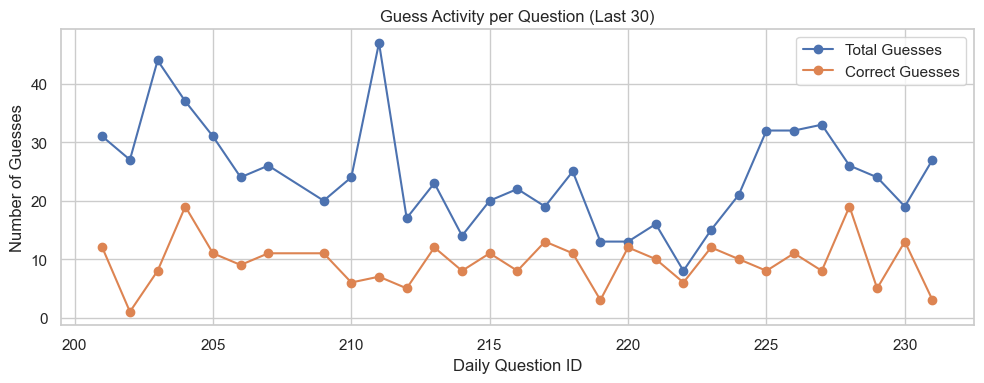

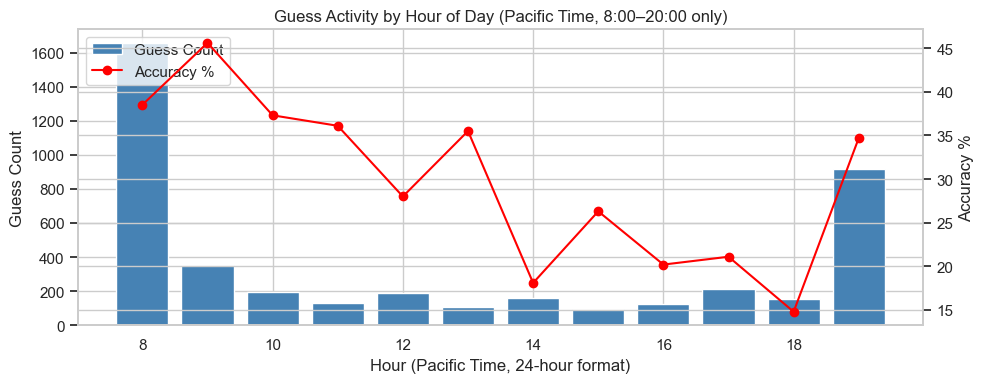


🧠 Before-Hint vs After-Hint Performance (hint at 19:00 PT):
  Before hint:  3375 guesses,  1156 correct (34.3% accuracy)
  After hint :   919 guesses,   319 correct (34.7% accuracy)

🎯 Correct Rate by Attempt Number:
  label  total_attempts  correct_count  success_rate
1st try            1728            863          49.9
2nd try             797            243          30.5
3rd try             511            156          30.5


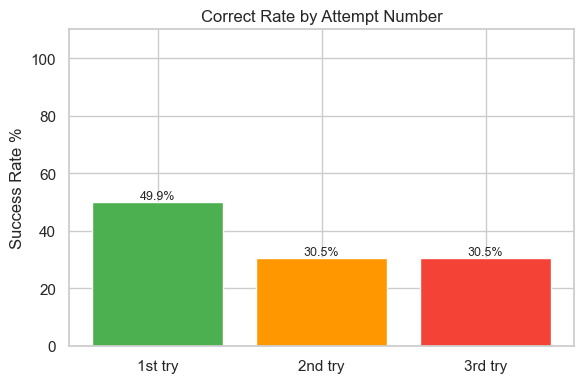


🔄 Top instances of multiple guesses on same question:
 player_name                                           question_preview  attempts
     Kristen                     What can be read but never written?...        36
       Blake                     What can be read but never written?...        30
    Kimberly           Do,Re,Mi,Fa,So,La,Ti,Do are examples of what?...        25
    Kimberly Despite the fact that it usually rolls by quite quickly...        22
       Blake                           What can run but has no legs?...        21
     Kristen                        Where does a bee collect pollen?...        20
bunnyfarts83 In Acts, after Tabitha dies, this early Christian leade...        19
       Kenny                           What can run but has no legs?...        18
       Kenny Where would you find the headwaters of the Mississippi ...        18
       Kenny          What state’s nickname is the “mountain state”?...        17


In [6]:
if "conn" in locals() and conn:
    # Overall guess statistics
    query = """
    SELECT
        COUNT(*) as total_guesses,
        COUNT(CASE WHEN is_correct = 1 THEN 1 END) as correct_guesses,
        COUNT(CASE WHEN is_correct = 0 THEN 1 END) as incorrect_guesses,
        ROUND(100.0 * COUNT(CASE WHEN is_correct = 1 THEN 1 END) / COUNT(*), 1) as overall_accuracy
    FROM guesses;
    """
    df_stats = pd.read_sql_query(query, conn)
    print("🎯 Overall Guess Statistics:")
    print(f"Total guesses: {df_stats.iloc[0]['total_guesses']}")
    print(f"Correct: {df_stats.iloc[0]['correct_guesses']}")
    print(f"Incorrect: {df_stats.iloc[0]['incorrect_guesses']}")
    print(f"Overall accuracy: {df_stats.iloc[0]['overall_accuracy']}%")

    # Guesses per day (last 30 questions)
    query = """
    SELECT
        daily_question_id,
        COUNT(*) as guess_count,
        COUNT(CASE WHEN is_correct = 1 THEN 1 END) as correct_count
    FROM guesses
    GROUP BY daily_question_id
    ORDER BY daily_question_id DESC
    LIMIT 30;
    """
    df_daily_guesses = pd.read_sql_query(query, conn)
    if not df_daily_guesses.empty:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(
            df_daily_guesses["daily_question_id"],
            df_daily_guesses["guess_count"],
            marker="o",
            label="Total Guesses",
        )
        ax.plot(
            df_daily_guesses["daily_question_id"],
            df_daily_guesses["correct_count"],
            marker="o",
            label="Correct Guesses",
        )
        ax.set_title("Guess Activity per Question (Last 30)")
        ax.set_xlabel("Daily Question ID")
        ax.set_ylabel("Number of Guesses")
        ax.legend()
        plt.tight_layout()
        plt.show()

    # Guess timing analysis — Pacific time, filtered to valid play window (8:00–20:00)
    # Guesses outside this range are from an early version of the game without play-hour enforcement
    PLAY_HOUR_START = 8  # matches JBOT_MORNING_TIME=8:00
    PLAY_HOUR_END = 20  # matches JBOT_EVENING_TIME=20:00

    query = """
    SELECT
        guessed_at,
        is_correct
    FROM guesses;
    """
    df_guesses_raw = pd.read_sql_query(query, conn)
    if not df_guesses_raw.empty:
        df_guesses_raw["guessed_at"] = pd.to_datetime(
            df_guesses_raw["guessed_at"], utc=True
        )
        df_guesses_raw["guessed_at_pt"] = df_guesses_raw["guessed_at"].dt.tz_convert(
            "America/Los_Angeles"
        )
        df_guesses_raw["hour"] = df_guesses_raw["guessed_at_pt"].dt.hour

        # Filter to valid play hours
        df_play = df_guesses_raw[
            (df_guesses_raw["hour"] >= PLAY_HOUR_START)
            & (df_guesses_raw["hour"] < PLAY_HOUR_END)
        ]

        df_hourly = (
            df_play.groupby("hour")
            .agg(
                guess_count=("is_correct", "count"),
                correct_count=("is_correct", "sum"),
            )
            .reset_index()
        )
        df_hourly["accuracy"] = (
            df_hourly["correct_count"] / df_hourly["guess_count"] * 100
        ).round(1)

        fig, ax1 = plt.subplots(figsize=(10, 4))
        ax1.bar(
            df_hourly["hour"],
            df_hourly["guess_count"],
            color="steelblue",
            label="Guess Count",
        )
        ax1.set_xlabel("Hour (Pacific Time, 24-hour format)")
        ax1.set_ylabel("Guess Count")
        ax2 = ax1.twinx()
        ax2.plot(
            df_hourly["hour"],
            df_hourly["accuracy"],
            color="red",
            marker="o",
            label="Accuracy %",
        )
        ax2.set_ylabel("Accuracy %")
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
        ax1.set_title(
            f"Guess Activity by Hour of Day (Pacific Time, {PLAY_HOUR_START}:00–{PLAY_HOUR_END}:00 only)"
        )
        plt.tight_layout()
        plt.show()

        # Before-hint vs after-hint performance
        # Hint sent at JBOT_REMINDER_TIME=19:00 PT
        HINT_HOUR = 19
        before = df_play[df_play["hour"] < HINT_HOUR]
        after = df_play[df_play["hour"] >= HINT_HOUR]
        print("\n🧠 Before-Hint vs After-Hint Performance (hint at 19:00 PT):")
        for label, subset in [("Before hint", before), ("After hint ", after)]:
            if not subset.empty:
                correct = int(subset["is_correct"].sum())
                total = len(subset)
                print(
                    f"  {label}: {total:5d} guesses, {correct:5d} correct "
                    f"({100 * correct / total:.1f}% accuracy)"
                )

    # Try-bonus breakdown: correct rate by attempt number (1st, 2nd, 3rd)
    query = """
    SELECT
        attempt_num,
        COUNT(*) as total_attempts,
        COUNT(CASE WHEN is_correct = 1 THEN 1 END) as correct_count,
        ROUND(100.0 * COUNT(CASE WHEN is_correct = 1 THEN 1 END) / COUNT(*), 1) as success_rate
    FROM (
        SELECT
            player_id,
            daily_question_id,
            is_correct,
            ROW_NUMBER() OVER (
                PARTITION BY player_id, daily_question_id
                ORDER BY guessed_at
            ) as attempt_num
        FROM guesses
    )
    WHERE attempt_num <= 3
    GROUP BY attempt_num
    ORDER BY attempt_num;
    """
    df_try = pd.read_sql_query(query, conn)
    if not df_try.empty:
        attempt_labels = {1: "1st try", 2: "2nd try", 3: "3rd try"}
        df_try["label"] = df_try["attempt_num"].map(attempt_labels)
        print("\n🎯 Correct Rate by Attempt Number:")
        print(
            df_try[
                ["label", "total_attempts", "correct_count", "success_rate"]
            ].to_string(index=False)
        )
        fig, ax = plt.subplots(figsize=(6, 4))
        colors_try = ["#4CAF50", "#FF9800", "#F44336"]
        bars = ax.bar(
            df_try["label"],
            df_try["success_rate"],
            color=colors_try[: len(df_try)],
        )
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{bar.get_height():.1f}%",
                ha="center",
                va="bottom",
                fontsize=9,
            )
        ax.set_title("Correct Rate by Attempt Number")
        ax.set_ylabel("Success Rate %")
        ax.set_ylim(0, 110)
        plt.tight_layout()
        plt.show()

    # Multiple guess analysis — player name + question preview
    query = """
    SELECT
        p.name as player_name,
        q.question_text,
        COUNT(*) as attempts
    FROM guesses g
    JOIN players p ON g.player_id = p.id
    JOIN daily_questions dq ON g.daily_question_id = dq.id
    JOIN questions q ON dq.question_id = q.id
    GROUP BY g.player_id, g.daily_question_id
    HAVING COUNT(*) > 1
    ORDER BY attempts DESC
    LIMIT 10;
    """
    df_multi = pd.read_sql_query(query, conn)
    if not df_multi.empty:
        df_multi["question_preview"] = df_multi["question_text"].str[:55] + "..."
        print("\n🔄 Top instances of multiple guesses on same question:")
        print(
            df_multi[["player_name", "question_preview", "attempts"]].to_string(
                index=False
            )
        )

## 7. Data Integrity & Sanity Checks

Verification checks for database consistency and potential issues.

In [7]:
if "conn" in locals() and conn:
    print("🔍 Database Integrity Checks:\n")

    # Check for orphaned records
    query = """
    SELECT COUNT(*) as orphaned_guesses
    FROM guesses g
    LEFT JOIN players p ON g.player_id = p.id
    WHERE p.id IS NULL;
    """
    orphaned = pd.read_sql_query(query, conn).iloc[0, 0]
    if orphaned > 0:
        print(f"⚠️  Warning: {orphaned} orphaned guesses (player not found)")
    else:
        print("✓ No orphaned guesses")

    # Check for questions without answers
    query = """
    SELECT COUNT(*) as missing_answers
    FROM questions
    WHERE answer_text IS NULL OR answer_text = '';
    """
    missing = pd.read_sql_query(query, conn).iloc[0, 0]
    if missing > 0:
        print(f"⚠️  Warning: {missing} questions missing answers")
    else:
        print("✓ All questions have answers")

    # Daily question continuity check
    query = """
    SELECT
        MIN(DATE(sent_at)) as first_question,
        MAX(DATE(sent_at)) as last_question,
        COUNT(DISTINCT DATE(sent_at)) as unique_days
    FROM daily_questions;
    """
    df_dates = pd.read_sql_query(query, conn)
    if not df_dates.empty and df_dates.iloc[0]["first_question"]:
        first = pd.to_datetime(df_dates.iloc[0]["first_question"])
        last = pd.to_datetime(df_dates.iloc[0]["last_question"])
        expected_days = (last - first).days + 1
        actual_days = df_dates.iloc[0]["unique_days"]

        print(f"\n📅 Daily Questions Timeline:")
        print(f"First question: {first.strftime('%Y-%m-%d')}")
        print(f"Last question: {last.strftime('%Y-%m-%d')}")
        print(f"Expected days: {expected_days}")
        print(f"Actual days with questions: {actual_days}")

        if expected_days != actual_days:
            print(f"⚠️  Warning: {expected_days - actual_days} days missing questions")

            query = """
            SELECT DATE(sent_at) as date
            FROM daily_questions
            ORDER BY sent_at;
            """
            df_all_dates = pd.read_sql_query(query, conn)
            date_range = pd.date_range(start=first, end=last)
            existing_dates = pd.to_datetime(df_all_dates["date"])
            missing_dates = date_range.difference(existing_dates)

            if len(missing_dates) > 0 and len(missing_dates) <= 10:
                print("\nMissing dates:")
                for date in missing_dates:
                    print(f"  - {date.strftime('%Y-%m-%d')}")
            elif len(missing_dates) > 10:
                print(f"\n  ({len(missing_dates)} dates missing - too many to list)")
        else:
            print("✓ No missing days")

    # Score adjustment audit
    query = """
    SELECT COUNT(*) as adjustment_count
    FROM score_adjustments;
    """
    adjustments = pd.read_sql_query(query, conn).iloc[0, 0]
    if adjustments > 0:
        print(f"\n📝 Total manual score adjustments: {adjustments}")

        query = """
        SELECT
            p.name as player,
            SUM(sa.amount) as total_adjustment
        FROM score_adjustments sa
        JOIN players p ON sa.player_id = p.id
        GROUP BY sa.player_id, p.name
        ORDER BY total_adjustment DESC
        LIMIT 5;
        """
        df_adj = pd.read_sql_query(query, conn)
        print("\nTop adjusted players:")
        print(df_adj.to_string(index=False))

    # Alternative answers
    query = """
    SELECT COUNT(DISTINCT question_id) as questions_with_alts
    FROM alternative_answers;
    """
    alt_count = pd.read_sql_query(query, conn).iloc[0, 0]
    print(f"\n✏️  Questions with alternative answers: {alt_count}")

    print("\n✅ Integrity check complete!")

🔍 Database Integrity Checks:

✓ No orphaned guesses
✓ All questions have answers

📅 Daily Questions Timeline:
First question: 2025-09-15
Last question: 2026-03-25
Expected days: 192
Actual days with questions: 188
⚠️  Warning: 4 days missing questions

Missing dates:
  - 2025-09-16
  - 2025-10-09
  - 2025-10-10
  - 2025-12-22

📝 Total manual score adjustments: 71

Top adjusted players:
  player  total_adjustment
   Kenny               635
Jonathan               539
Kimberly               491
   Blake               461
   lanie               427

✏️  Questions with alternative answers: 7

✅ Integrity check complete!


## 8. Advanced Metrics & Insights

Deeper analysis combining multiple data sources for strategic insights.

🎖️ Player Engagement Rankings (participation × accuracy × streak):
     player_name  days_played  accuracy  total_score  streak  engagement_score
           lanie          164      48.5        23502       8        143.154217
        Kimberly          126      30.0        17202      15         94.582245
         TaoMike          129      43.2        19132       6         89.194286
           Blake          183      32.3        23019       4         82.676173
       Juniornlx          143      35.4        15863       4         70.840000
           Kenny          162      23.8        19252       7         65.639378
         Kristen          152      32.9        18441       3         65.069249
    bunnyfarts83          124      27.2        15841       4         47.183590
      DrKnickers          112      37.1        13566       1         45.664865
        Jonathan          114      36.6        11560       0         41.728302
          Shiver           57      52.3         9490       3    

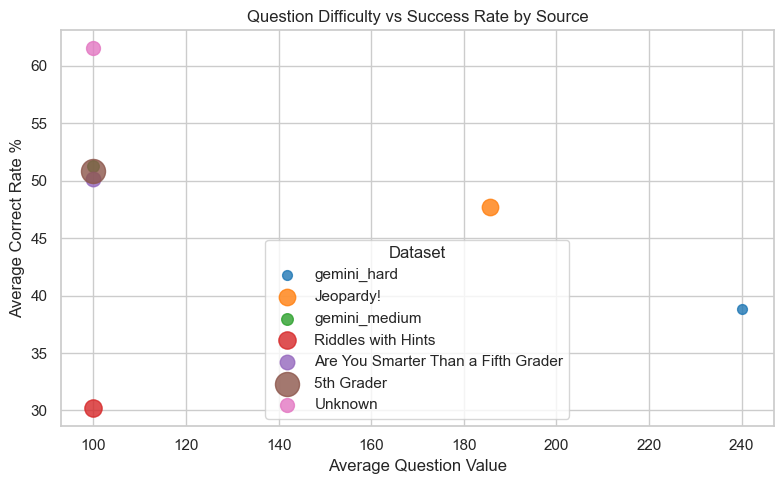


⚡ Power-Up Effectiveness (avg score increase on powerup day):
 powerup_type  usage_count  unique_users  avg_score_increase
         jinx           32             6               126.6
    jinx_late            1             1               225.0
 jinx_preload            1             1               340.0
         rest           28             8                10.6
  rest_wakeup           15             6               221.4
       shield            9             1               145.0
        steal           42             8               167.6
steal_preload            1             1               240.0


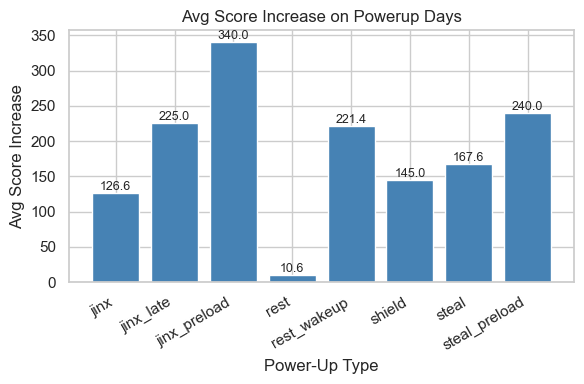

In [8]:
if "conn" in locals() and conn:
    # Player engagement score (combines participation, accuracy, and consistency)
    query = """
    SELECT
        p.name as player_name,
        COUNT(DISTINCT g.daily_question_id) as days_played,
        ROUND(100.0 * COUNT(CASE WHEN g.is_correct = 1 THEN 1 END) / COUNT(g.id), 1) as accuracy,
        p.score as total_score,
        p.answer_streak as streak,
        (COUNT(DISTINCT g.daily_question_id) *
         (100.0 * COUNT(CASE WHEN g.is_correct = 1 THEN 1 END) / COUNT(g.id)) / 100.0 *
         (1 + p.answer_streak * 0.1)) as engagement_score
    FROM players p
    JOIN guesses g ON p.id = g.player_id
    GROUP BY p.id, p.name, p.score, p.answer_streak
    HAVING COUNT(g.id) >= 5
    ORDER BY engagement_score DESC
    LIMIT 15;
    """
    df_engagement = pd.read_sql_query(query, conn)
    print("🎖️ Player Engagement Rankings (participation × accuracy × streak):")
    print(df_engagement.to_string(index=False))

    # Question difficulty vs participation (bubble scatter)
    query = """
    SELECT
        q.source as dataset_source,
        ROUND(AVG(q.value), 1) as avg_difficulty,
        COUNT(DISTINCT dq.id) as times_asked,
        ROUND(AVG(guess_counts.total_guesses), 1) as avg_guesses_per_question,
        ROUND(AVG(guess_counts.correct_rate), 1) as avg_correct_rate
    FROM questions q
    JOIN daily_questions dq ON q.id = dq.question_id
    JOIN (
        SELECT
            daily_question_id,
            COUNT(*) as total_guesses,
            100.0 * COUNT(CASE WHEN is_correct = 1 THEN 1 END) / COUNT(*) as correct_rate
        FROM guesses
        GROUP BY daily_question_id
    ) guess_counts ON dq.id = guess_counts.daily_question_id
    GROUP BY q.source
    ORDER BY avg_difficulty DESC;
    """
    df_difficulty_engagement = pd.read_sql_query(query, conn)
    if not df_difficulty_engagement.empty:
        df_difficulty_engagement["dataset_source"] = df_difficulty_engagement[
            "dataset_source"
        ].fillna("Unknown")

        print("\n📊 Dataset Difficulty vs Player Engagement:")
        print(df_difficulty_engagement.to_string(index=False))

        fig, ax = plt.subplots(figsize=(8, 5))
        sources = df_difficulty_engagement["dataset_source"].unique()
        colors = plt.cm.tab10(range(len(sources)))
        for src, color in zip(sources, colors):
            row = df_difficulty_engagement[
                df_difficulty_engagement["dataset_source"] == src
            ]
            ax.scatter(
                row["avg_difficulty"],
                row["avg_correct_rate"],
                s=row["times_asked"] * 5,
                color=color,
                alpha=0.8,
                label=src,
            )
        ax.set_title("Question Difficulty vs Success Rate by Source")
        ax.set_xlabel("Average Question Value")
        ax.set_ylabel("Average Correct Rate %")
        ax.legend(title="Dataset")
        plt.tight_layout()
        plt.show()

    # Power-up effectiveness: avg score increase on the day a powerup was used
    # Compares the player's snapshot at the start of the powerup day vs. the next snapshot
    query = """
    SELECT
        pu.powerup_type,
        COUNT(*) as usage_count,
        COUNT(DISTINCT pu.user_id) as unique_users,
        ROUND(AVG(dps_next.score - dps_curr.score), 1) as avg_score_increase
    FROM powerup_usage pu
    JOIN daily_player_states dps_curr
        ON pu.user_id = dps_curr.player_id
        AND pu.question_id = dps_curr.daily_question_id
    JOIN daily_player_states dps_next
        ON pu.user_id = dps_next.player_id
        AND dps_next.daily_question_id = (
            SELECT MIN(d2.daily_question_id)
            FROM daily_player_states d2
            WHERE d2.player_id = pu.user_id
              AND d2.daily_question_id > pu.question_id
        )
    WHERE pu.question_id IS NOT NULL
    GROUP BY pu.powerup_type;
    """
    df_powerup_effect = pd.read_sql_query(query, conn)
    if (
        not df_powerup_effect.empty
        and df_powerup_effect["avg_score_increase"].notna().any()
    ):
        print("\n⚡ Power-Up Effectiveness (avg score increase on powerup day):")
        print(df_powerup_effect.to_string(index=False))

        fig, ax = plt.subplots(figsize=(6, 4))
        bars = ax.bar(
            df_powerup_effect["powerup_type"],
            df_powerup_effect["avg_score_increase"].fillna(0),
            color="steelblue",
        )
        for bar in bars:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{bar.get_height():.1f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
        ax.set_title("Avg Score Increase on Powerup Days")
        ax.set_xlabel("Power-Up Type")
        ax.set_ylabel("Avg Score Increase")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print(
            "\n⚡ Power-Up Effectiveness: insufficient data (need daily_player_states snapshots)"
        )

## 9. Cleanup

Close the database connection.

In [9]:
if "conn" in locals() and conn:
    conn.close()
    print("✓ Database connection closed successfully.")

✓ Database connection closed successfully.
